# Setup

In [2]:
!wget -q https://raw.githubusercontent.com/PhilBurub/Evaluating-GAN-and-VAE-for-Image-Captioning/refs/heads/main/code/utils.py
!wget -q https://raw.githubusercontent.com/PhilBurub/Evaluating-GAN-and-VAE-for-Image-Captioning/refs/heads/main/code/architectures/adapter.py
!wget -q https://raw.githubusercontent.com/PhilBurub/Evaluating-GAN-and-VAE-for-Image-Captioning/refs/heads/main/code/architectures/lm-decoding/gan_trainer.py
!wget -q https://raw.githubusercontent.com/PhilBurub/Evaluating-GAN-and-VAE-for-Image-Captioning/refs/heads/main/code/architectures/lm-decoding/vae_trainer.py
!wget -q https://raw.githubusercontent.com/PhilBurub/Evaluating-GAN-and-VAE-for-Image-Captioning/refs/heads/main/code/architectures/lm-decoding/baseline_trainer.py
!wget -q https://raw.githubusercontent.com/PhilBurub/Evaluating-GAN-and-VAE-for-Image-Captioning/refs/heads/main/data/ds_captions.json

In [3]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig,
    AutoImageProcessor,
    AutoModel
)
from PIL import Image
from adapter import ImageConvAdapter
from vae_trainer import VAEImageDescriptionTrainer
from gan_trainer import GANImageDescriptionTrainer
from baseline_trainer import QwenImageDescriptionTrainer
from torch.utils.data import DataLoader
from utils import (
    _set_env,
    embed,
    get_collator
)
from torchvision.io import read_image
from nltk.translate.bleu_score import sentence_bleu
import pandas as pd
import torch
import wandb
import json
import re

_set_env("WANDB_API_KEY")

2026-05-05 16:35:10.308000: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777998910.494127      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777998910.548076      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777998910.982839      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777998910.982882      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777998910.982885      57 computation_placer.cc:177] computation placer alr

WANDB_API_KEY:  ········


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Data

In [5]:
images_path = '/kaggle/input/datasets/adityajn105/flickr30k/Images/flickr30k_images/'
captions = pd.read_json('ds_captions.json', orient='records')
captions.split.value_counts()

split
train    22220
test      6350
val       3174
Name: count, dtype: int64

# Image Model

In [6]:
image_model_name = 'facebook/dinov2-base'
image_processor = AutoImageProcessor.from_pretrained(image_model_name, use_fast=True)
image_model = AutoModel.from_pretrained(image_model_name).to(device)

image_emb_sample = embed(
    [read_image(images_path + image) for image in captions.head().image],
    image_model,
    image_processor,
    device
)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

# Language Model

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer

qwen_model_name = "Qwen/Qwen3-0.6B"
qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_model_name)
qwen_model = AutoModelForCausalLM.from_pretrained(qwen_model_name).to(device)

qwen_hidden_size = qwen_model.config.hidden_size
image_model_hidden_size = image_emb_sample.shape[-1]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

# Dataloaders

In [8]:
test_collate = get_collator(
    image_model,
    image_processor,
    '',
    device,
    images_path,
    first_only=False
)

test_loader = DataLoader(
    captions[captions.split == 'test'].to_dict(orient='records'),
    batch_size=16,
    shuffle=False,
    collate_fn=test_collate
)

# Adapter Initialization

In [ ]:
api = wandb.Api()
artifact = api.artifact("pburub/gan-vae-image-captioning/2_checkpoint:v9")
artifact_dir = artifact.download()

adapter = torch.load(artifact_dir + '/2_checkpoint.model', weights_only=False).to(device)
placeholder = torch.nn.Linear(1, 1)

wandb:   1 of 1 files downloaded.  


In [15]:
trainer = GANImageDescriptionTrainer(
    placeholder,
    qwen_model,
    qwen_tokenizer,
    adapter,
    device,
    lr=0.005
)

# Training Loop

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


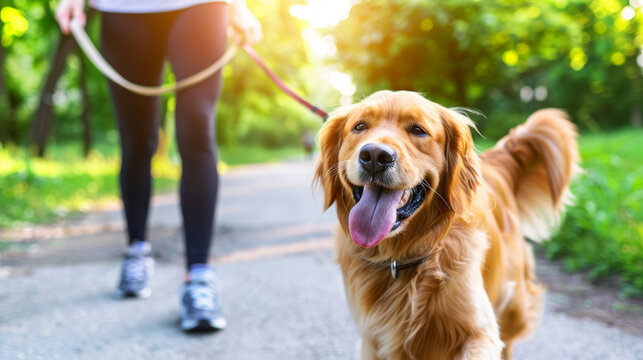

In [16]:
!wget -q -O test.jpg https://t3.ftcdn.net/jpg/08/47/24/16/360_F_847241667_j8N9LSkZkHlvSr0c6rUnpzjJEQftBUSH.jpg
from PIL import Image

test_image = Image.open('test.jpg')
test_image

In [17]:
trainer.generate(
    embed(
        [read_image('test.jpg')],
        image_model,
        image_processor,
        device
    )
)

['Two20000 is the\n\n\n\n\n\n\n\n\n\n\n\n']

In [18]:
for image_embs, _ in test_loader:
    break
trainer.generate(image_embs)

['A\n\n# 1.1.1.1.1.1.1.1',
 'A\n\n# 100000000000000',
 'A1\n# This is a problem where the user is asking for the answer to the problem.',
 "A1\n\n#1. Let's use the image to solve the problem.\n\n#Problem\n#",
 'A1\n\n# Let me think about the code to solve the problem. If the answer is',
 'A2000000000000000000',
 'A100. image. image. image. image. image. image. image. image',
 'A100000\n\n\n\n\n\n\n\n\n\n\n\n\n',
 'A\n\n!image\n!image\n!image\n!image\n!image\n!image\n',
 "A100\n\n# Let's use the first step to solve the problem.\n\n",
 'A1.0.0.1. (1) is the image.1.0.',
 'A\n\n#1\n#1\n#1\n#1\n#1\n#1',
 'A100000\n\n\n\n\n\n\n\n\n\n\n\n\n',
 'A1\nimport numpy as np\n\n# Create a list of the first 10 numbers in',
 "Two of the user is a girl, and the user is a girl. 1. Let's",
 "A1\nimport numpy as np\n# This is a problem. Let's use the image to"]